# END-TO-END PIPELINE

## Purpose of the notebook

This notebook includes an end-to-end pipeline prepared to run a detailed analysis of Xenium samples. It includes tasks such as:
1. **Formatting xenium output to AnnData files**, filtering reads by distance to nuclei or quality
2. **Resegmenting cells using Baysor** (using Docker/Singularity)
3. **Preprocessing and clustering cells** in the experiment, generating spatial maps and differentially expressed genes
4. **Imputing gene expression** using SpaGE
5. **Domain identification** using Banksy(preferred) ,neighbor-based domains or  read-based domains
6. **Identifying Spatially variable genes** using Squidpy's Moran's I
7. **Defining celltype neighborhood enrichment** using Squidpy

## Import packages

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from xb.formatting import *
from xb.plotting import *
from xb.preprocessing import *
from xb.Spage_main import *
from xb.calculating import *

## 0. Defining input parameters  

We first define some basic information for our path including: 
- **Files**: list including the paths where your Xenium output is stored for each experiment
- **Output_path**: directory where you want to save the ouptut of your pipeline
- **save**: whether you want to save intermediate files and plots
- **plot_path**: path to the directory where figures generated should be saved, if applicable

**OBS! Downloading example dataset:**
For downloading Xenium example dataset, please use the following link:
https://doi.org/10.5281/zenodo.11612060 and include the path of the downloaded files under ``files``


In [7]:
# files=['./data/data_end_to_end_pipeline/output-XETG00047__0011146__1886C__20231102__180733',
#       './data/data_end_to_end_pipeline/output-XETG00047__0011146__1886P__20231102__180733']

files=['./data/lv_spatialdat_liu/lv_0046706',
      './data/lv_spatialdat_liu/lv_0046859']

output_path=r'../pipeline_output_single_tissue/'
save=True ## Saving intermediate outputs
plot_path=output_path+'/figures/'

## 1. Format Xenium output to AnnData

First, we will format the Xenium datasets to AnnData format, filtering in the process reads that have either too low quality or that are too far away from the segmented cell body. Fo this we need to define two parameters:
- **Max_nucleus_distance**: maximum distance from the reads to each closest cell to consider reads in the definition of cells
- **min_quality**: minimum quality of reads to be kept in the analysis

In [9]:
max_nucleus_distance=10
min_quality=0

Now we run the function `format_to_adata` to format Xenium's output to AnnData

In [10]:
adata=format_to_adata(files=files,output_path=output_path,max_nucleus_distance=max_nucleus_distance,min_quality=min_quality,save=save)

Formatting lv_0046706


/home/chrism/git/Xenium_benchmarking/xb/formatting.py:536: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata=sc.AnnData(ad.transpose(),obs=cell_info,var=features)
/home/chrism/miniconda3/envs/xb/lib/python3.7/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Filter reads


/home/chrism/git/Xenium_benchmarking/xb/formatting.py:628: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata1nuc=sc.AnnData(np.array(ct1),obs=adataobs,var=av)


Formatting lv_0046859


/home/chrism/git/Xenium_benchmarking/xb/formatting.py:536: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata=sc.AnnData(ad.transpose(),obs=cell_info,var=features)
/home/chrism/miniconda3/envs/xb/lib/python3.7/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Filter reads


/home/chrism/git/Xenium_benchmarking/xb/formatting.py:628: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata1nuc=sc.AnnData(np.array(ct1),obs=adataobs,var=av)
/home/chrism/miniconda3/envs/xb/lib/python3.7/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 2. Resegmentation using Baysor (Alternative to #1)

Alternatively to define cells based on Xenium's segmentation, we can also perform Baysor, which we observed to perform slightly better in terms of number of assigned transcripts. For this, we first pormat the Xenium's to get the input needed for baysor

Note that we also have this functionk in a batch for for multiple inputs. It's called  `batch_prep_xenium_data_for_baysor` and accepts a list of xenium outputs, stored in `files` as an input. However, it doesn't accept to process a crop. 

In [13]:
prep_xenium_data_for_baysor(files[1], output_path,CROP=True, COORDS=[1000, 5000, 1000, 5000])

CHECKPOINT 1: Output directory created
CHECKPOINT 2: Spots loaded
CHECKPOINT 3: Spots converted to pixel units
CHECKPOINT 4: Spots cropped
CHECKPOINT 5: Polygons loaded
CHECKPOINT 6: Polygons cropped


ValueError: zero-size array to reduction operation maximum which has no identity

Next, we will perform Baysor. Since Baysor is implemented in Julia and has its own required environment, we will run it using Docker. First we get the docker we need. Please remember to install docker before if required (https://docs.docker.com/get-docker/). Please run this part from the command line if needed. **IMPORTANT** We recommend to run this part directly in your command line in case you need to run it as a superuser (with sudo) 

In [12]:
!docker pull louisk92/txsim_baysor:v0.6.2bin

v0.6.2bin: Pulling from louisk92/txsim_baysor

8493d397: Pulling fs layer 
02bd5ed6: Pulling fs layer 
5b0c455c: Pulling fs layer 
b8af2e23: Pulling fs layer 
28de0d04: Pulling fs layer 
aea940eb: Pulling fs layer 
c02eb358: Pulling fs layer 
28de0d04: Waiting fs layer 
e7a6957a: Pull complete .76MB/70.76MBBDigest: sha256:f13ab7c0791f92023d0ae26a889ac61801c6f17a86c31019ba41aac3f7b5eb84
Status: Downloaded newer image for louisk92/txsim_baysor:v0.6.2bin
docker.io/louisk92/txsim_baysor:v0.6.2bin


After that we run the docker container, and within it we run baysor. **IMPORTANT** We recommend to run this part directly in your command line in case you need to run it as a superuser (with sudo) 

In [ ]:
# we first run the docker, specifying the path tto the baysor input/output after the fist -v and also the path where the main we will use to run baysor is stored
!sudo docker run -it --rm -v /media/sergio/xenium_b_and_heart/pipeline_output/output-XETG00045__0011129__1225C__20231116__105020_baysor:/media/sergio/xenium_b_and_heart/pipeline_output/output-XETG00045__0011129__1225C__20231116__105020_baysor -v /media/sergio/xenium_b_and_heart/actual_repo/Xenium_benchmarking/xb:/media/sergio/xenium_b_and_heart/actual_repo/Xenium_benchmarking/xb louisk92/txsim_baysor:v0.6.2bin
# next we change directory to the directory where the run_baysor.sh script is.
!cd /media/sergio/xenium_b_and_heart/actual_repo/Xenium_benchmarking/xb
# finally, we run baysor
!bash run_baysor.sh "/media/sergio/xenium_b_and_heart/pipeline_output/output-XETG00045__0011129__1225C__20231116__105020_baysor"

Finally, we define in `path` where is the output of baysor stored and we format it to anndata. From here, we can continue to step 3 without major issues

In [11]:
patha='/media/sergio/xenium_b_and_heart/pipeline_output/output-XETG00045__0011129__1225C__20231116__105020_baysor'
adata=format_baysor_output_to_adata(path,output_path)

## 3. Preprocess and cluster cells AnnData

Next we will preprocess cells in our Xenium experiments and cluster them. For this we need to define multiple preprocessing and clustering parameters, present in `clustering_params`. Within this, we need to define:

- **normalization_target_sum**: Target sum to use if the normalization is done based on library size. None is used for automatic calculation of library size
- **min_counts_x_cell**:Minimum amount of counts detected in a cell to pass the quality filters
- **min_genes_x_cell**: Minimum amount of genes expressed in a cell to pass the quality filters
- **hvg(boolean)**: whether to select highly variable genes for further processing or not
- **clustering_alg**: which clustering algorithm to use (either louvain or leiden
- **resolutions**: which resolutions to use when clustering
- **n_neighbors**: number of neighbors to used when calculating the nearest neighbors by sc.pp.neighbors()
- **umap_min_dist**: minimum distance when computing UMAP
- **n_pcs**: number of principal components to used when calculating the nearest neighbors by sc.pp.neighbors()

The default parameters specified in the example correspond to the parameters found to be optimal when defining best practice. However, we always recommend to adjust them to your own convenience.

In [3]:
# Formatting filesand preprocessing
clustering_params={'normalization_target_sum':100,
'min_counts_x_cell':40,
'min_genes_x_cell':15,
'scale':False,
'clustering_alg':'louvain',
'resolutions':[0.2,0.5,1.1],
'n_neighbors':15,'umap_min_dist':0.1,
'n_pcs':0}

[OPTIONAL] Read again the data

In [11]:
adata=sc.read("/home/chrism/datasets/lv_0046859_002.h5ad")

## Preprocess adata using predefined parameters

KeyError: 'expressed_genes'

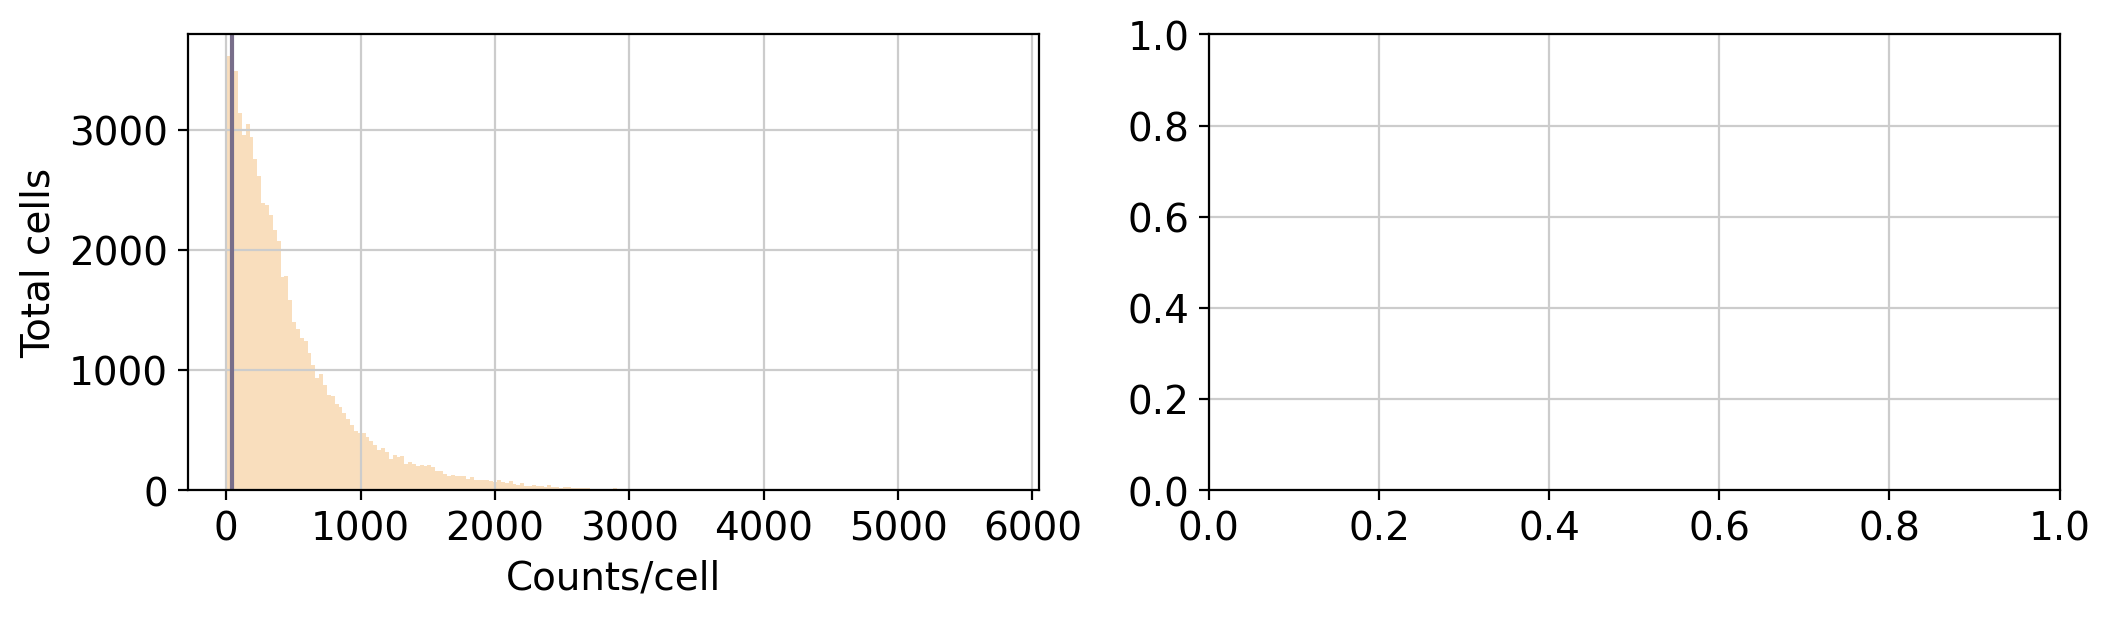

In [13]:
adata=preprocess_adata(adata,save=True,clustering_params=clustering_params,output_path=output_path)

## 4.  Domain identification (use any of the following algorithms in 4.1-3)

### 4.1 Banksy's domain identification

[OPTIONAL] Read again the data

In [17]:
adata=sc.read(output_path+'combined_processed.h5ad')

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../pipeline_output_single_tissue/combined_processed.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

#### Import required packages

In [14]:
import sys
from os.path import dirname
sys.path.append("./Banksy_py")

from xb.domain_identification import *
import random
random_seed = 1234
np.random.seed(random_seed)

We first define Bansky's hyperparameters. In summary, this is what they are:
- **resolutions**: clustering resolutions for clustering
- **cluster_algorithm**: clustering algorithm to use in the definition of domain ('leiden,'louvain')
- **pca_dims**: number of principal components used to identify the domains in situ
- **lambda_list**: lambda's parameters to be used when identifying domain. This is, in proportion, how much do you rely on the expression of each cell vs its neighbors. Values close to 1 are used for relying on the expression of neighboring cells (for domain identifications). Values close to 0 are used for regular clustering with little to no influence of neighboring cells
- **k_geom**: number of spatial neighbors of each cell to consider in the definition of each cell based on neighboring cells
- **max_m'**: indicates whether to use the AGF (max_m = 1) or just the mean expression (max_m = 0). By default, we set max_m = 1.
- **nbr_weight_decay'** : how we assign weights (dependent on inter-cell spatial distances) to edges in the connected spatial graph. By default, we use the gaussian decay option, where weights decay as a function of distnace to the index cell with = sigma. As default, we set to be the median distance between cells, and do not prescribe any cutoff-radius p_outside (no cutoff is conducted).

Please refer to Banksy's original publication Singhal et al. 2024

In [15]:
'''Input File'''
banksy_params={'resolutions':[.9], # clustering resolution for Leiden clustering
'pca_dims':[20], # number of dimensions to keep after PCA
'lambda_list':[.8],# lambda
'k_geom':15, # 15 spatial neighbours
'max_m':1, # use AGF
'nbr_weight_decay':"scaled_gaussian", # can also be "reciprocal", "uniform" or "ranked"
'cluster_algorithm':'leiden'}

## Run Banksy

In [16]:
adata,adata_banksy=domains_by_banksy(adata,plot_path=plot_path,banksy_params=banksy_params,save=save)

KeyError: 'x_centroid'

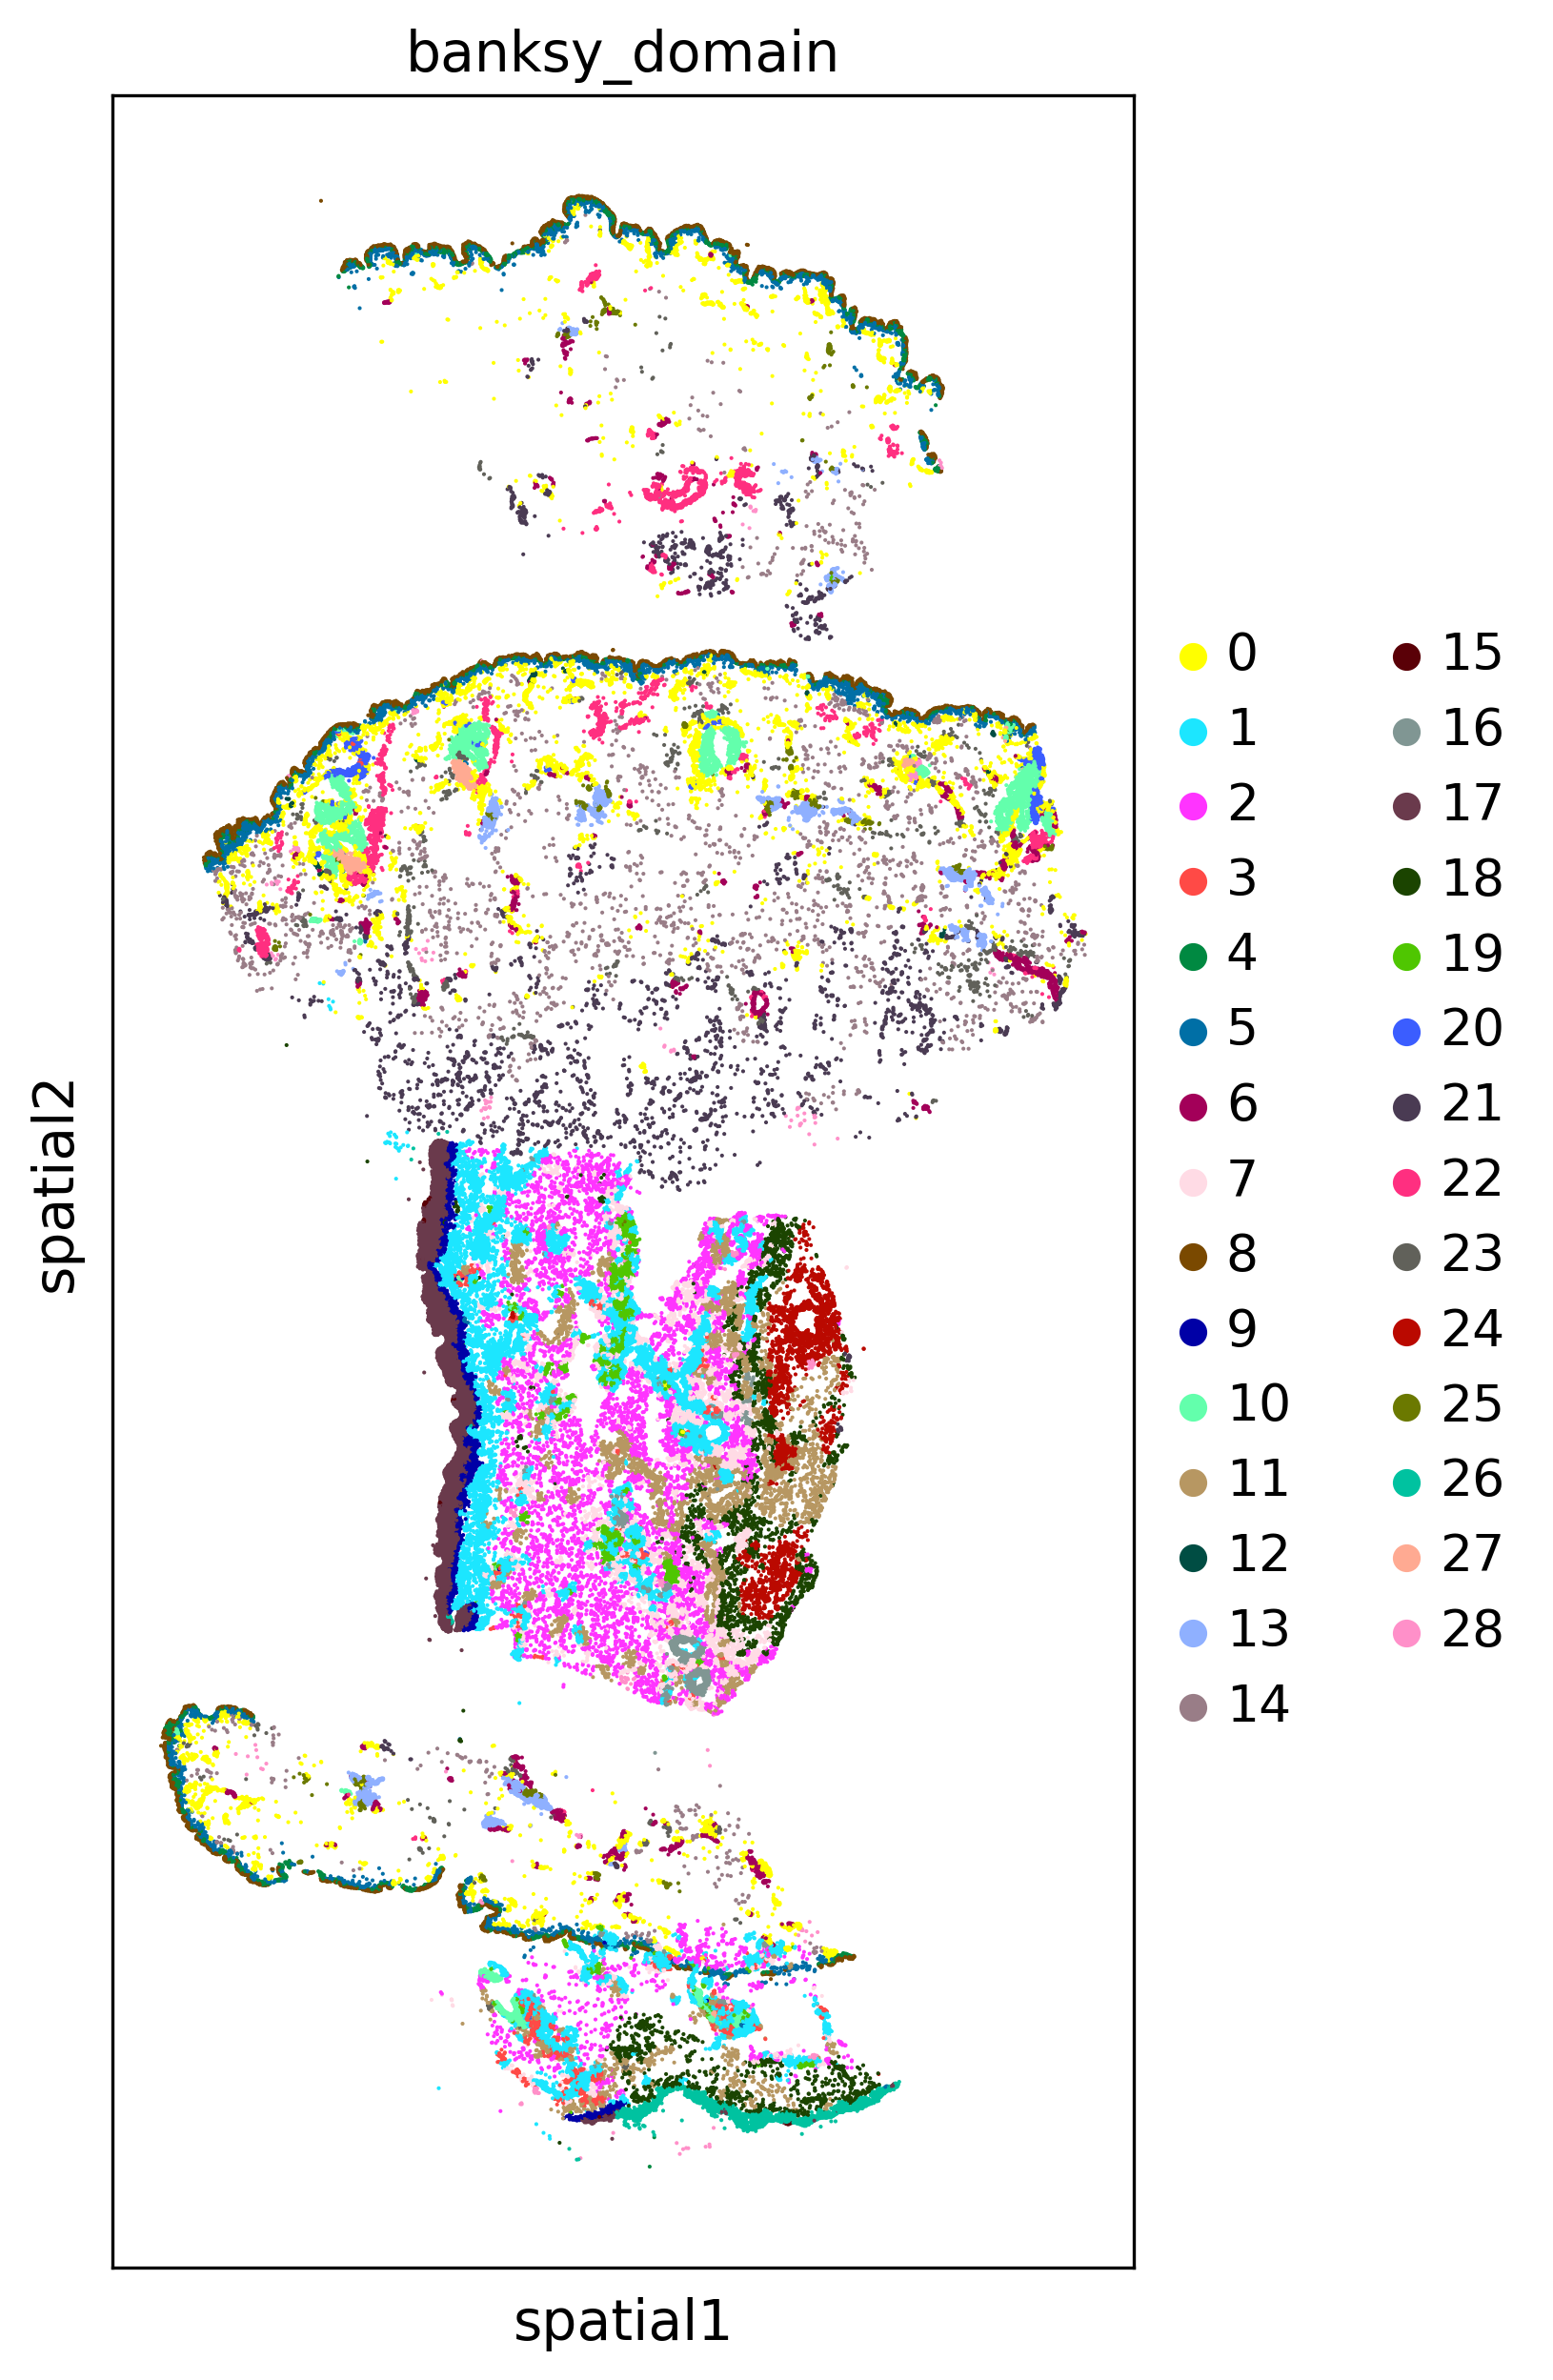

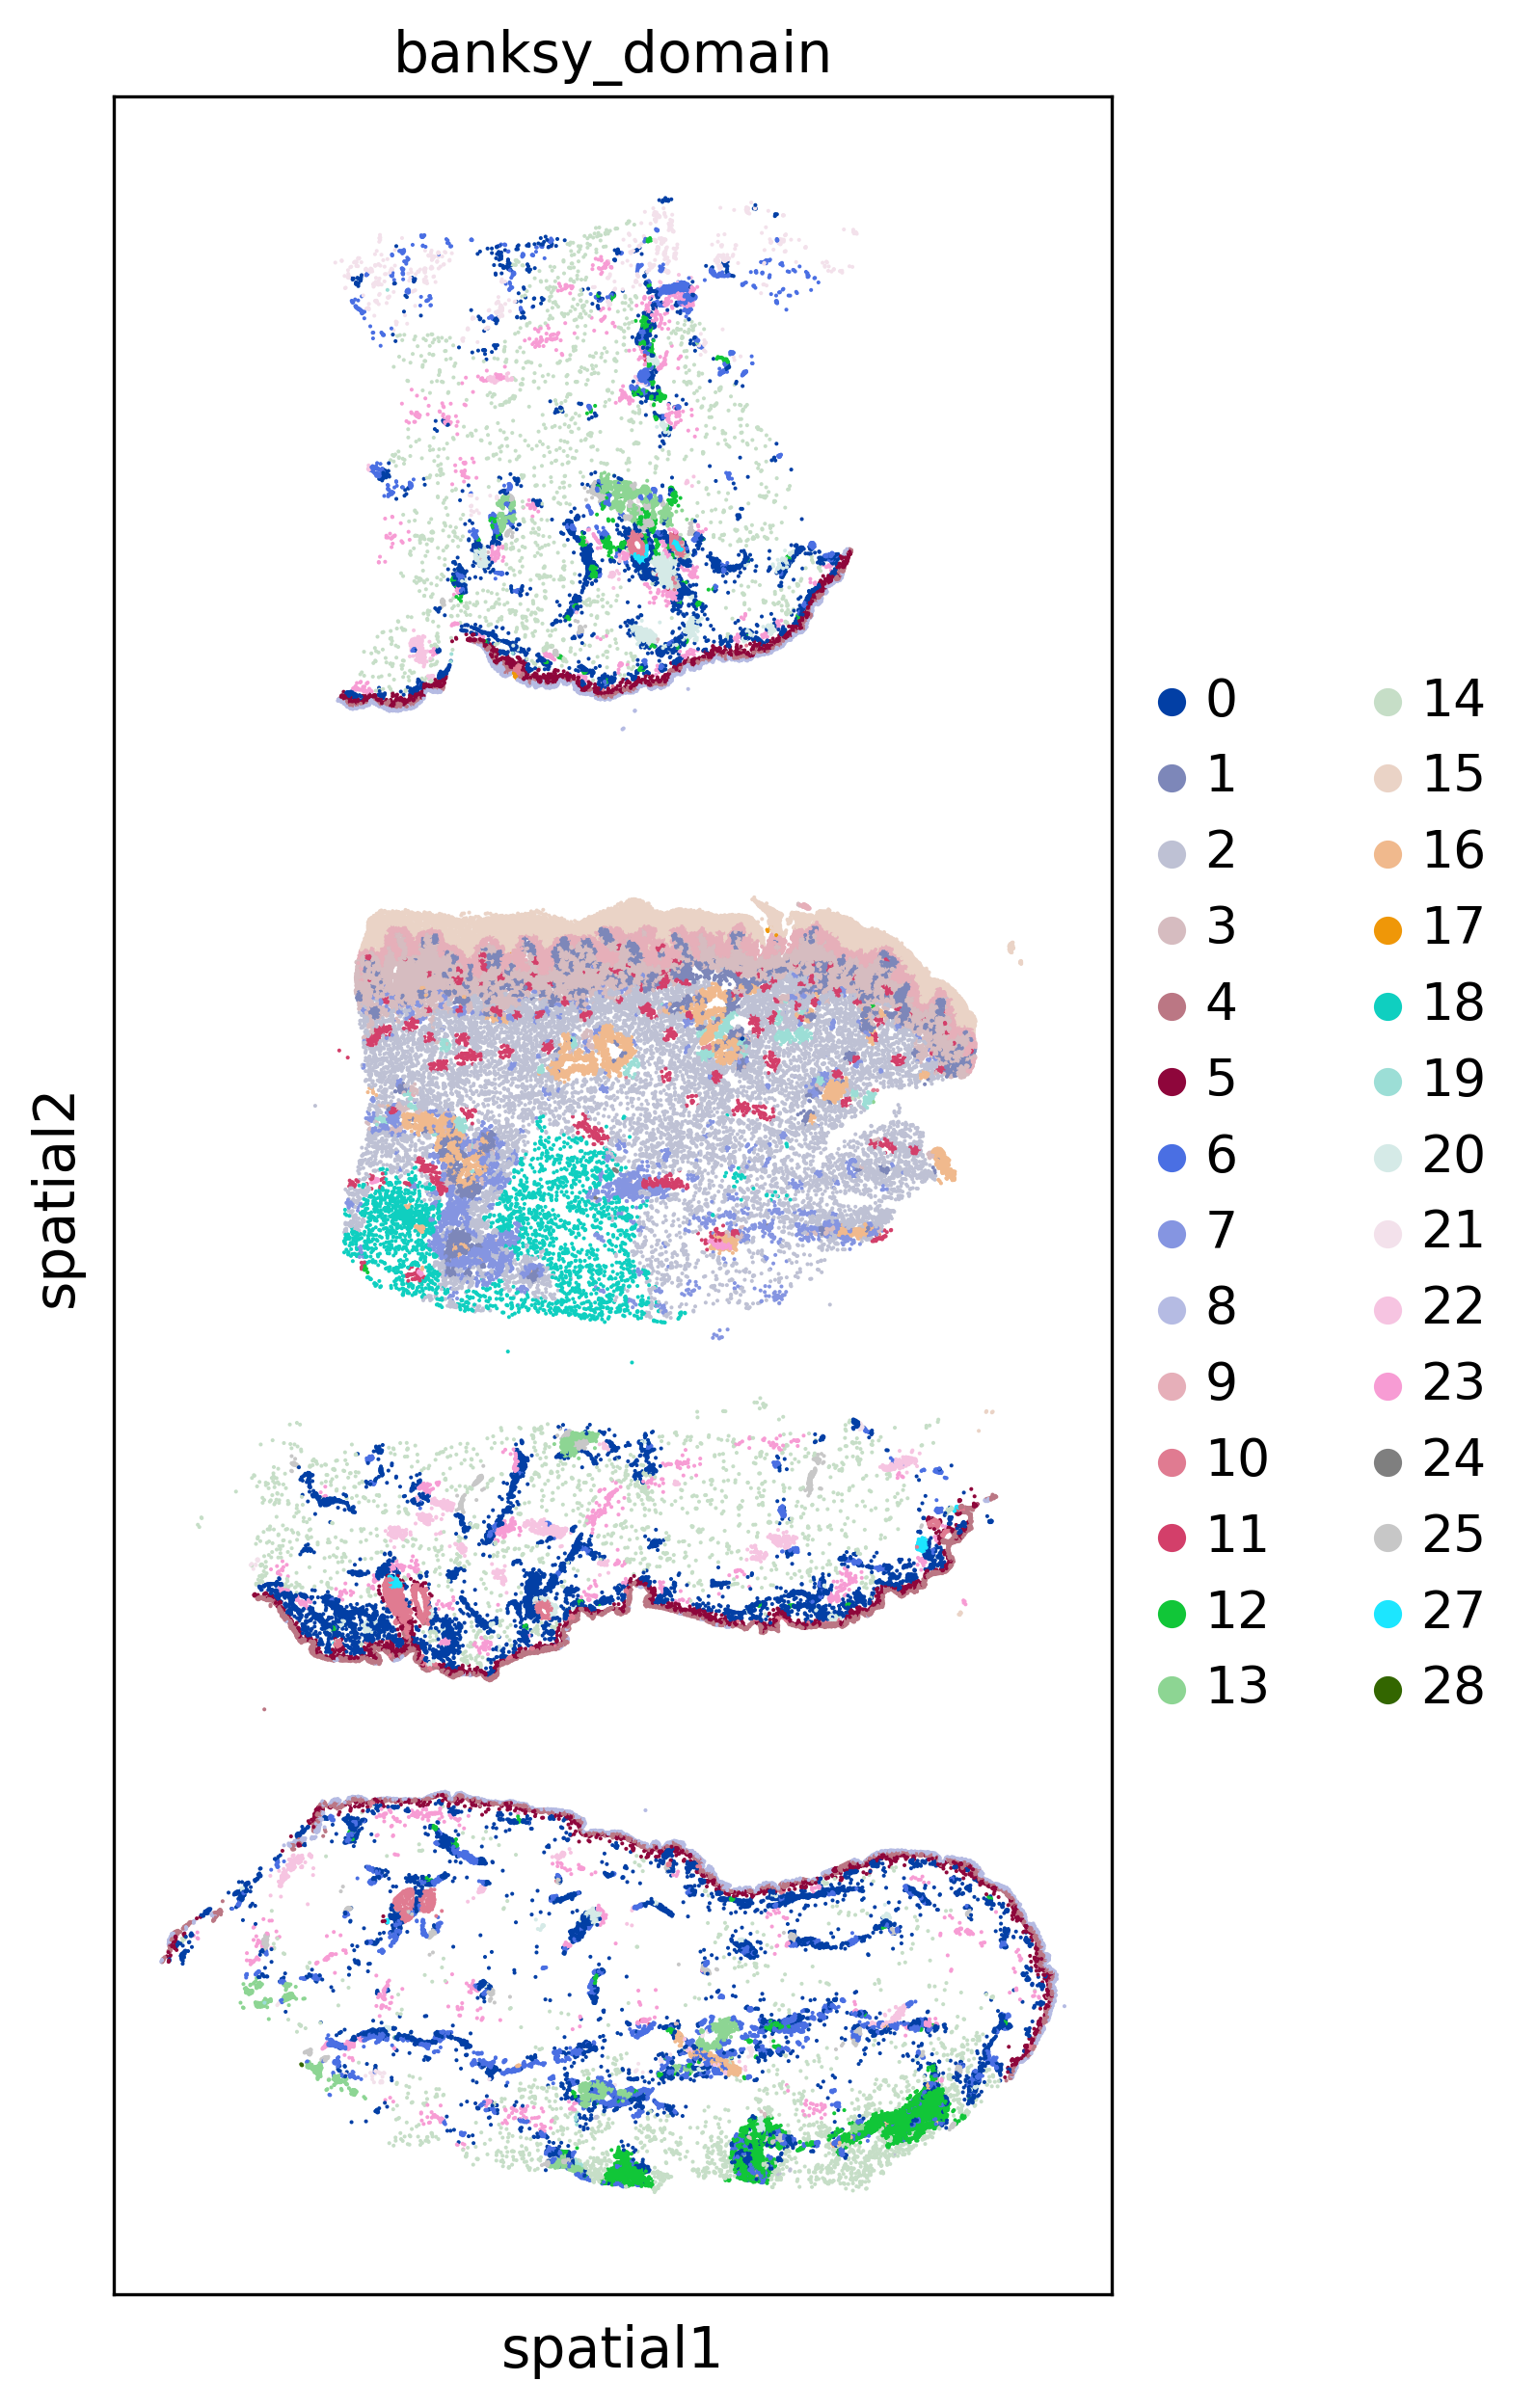

In [26]:
for s in adata.obs['sample'].unique():
        adatasub=adata[adata.obs['sample']==s]
        sc.pl.spatial(adatasub,color='banksy_domain',spot_size=40)

### 4.2 Neighbors-based domain identification (NBD)

In [27]:
from xb.formatting import format_data_neighs
hyperparameters_nbd={'key':'louvain_1.1','resolution':1.0,'neighbors':15,'clustering_algorithm':'leiden'}

In [28]:
adata,adata_nbd=domains_by_nbd(adata,hyperparameters_nbd=hyperparameters_nbd)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:00<00:00, 47.01it/s]


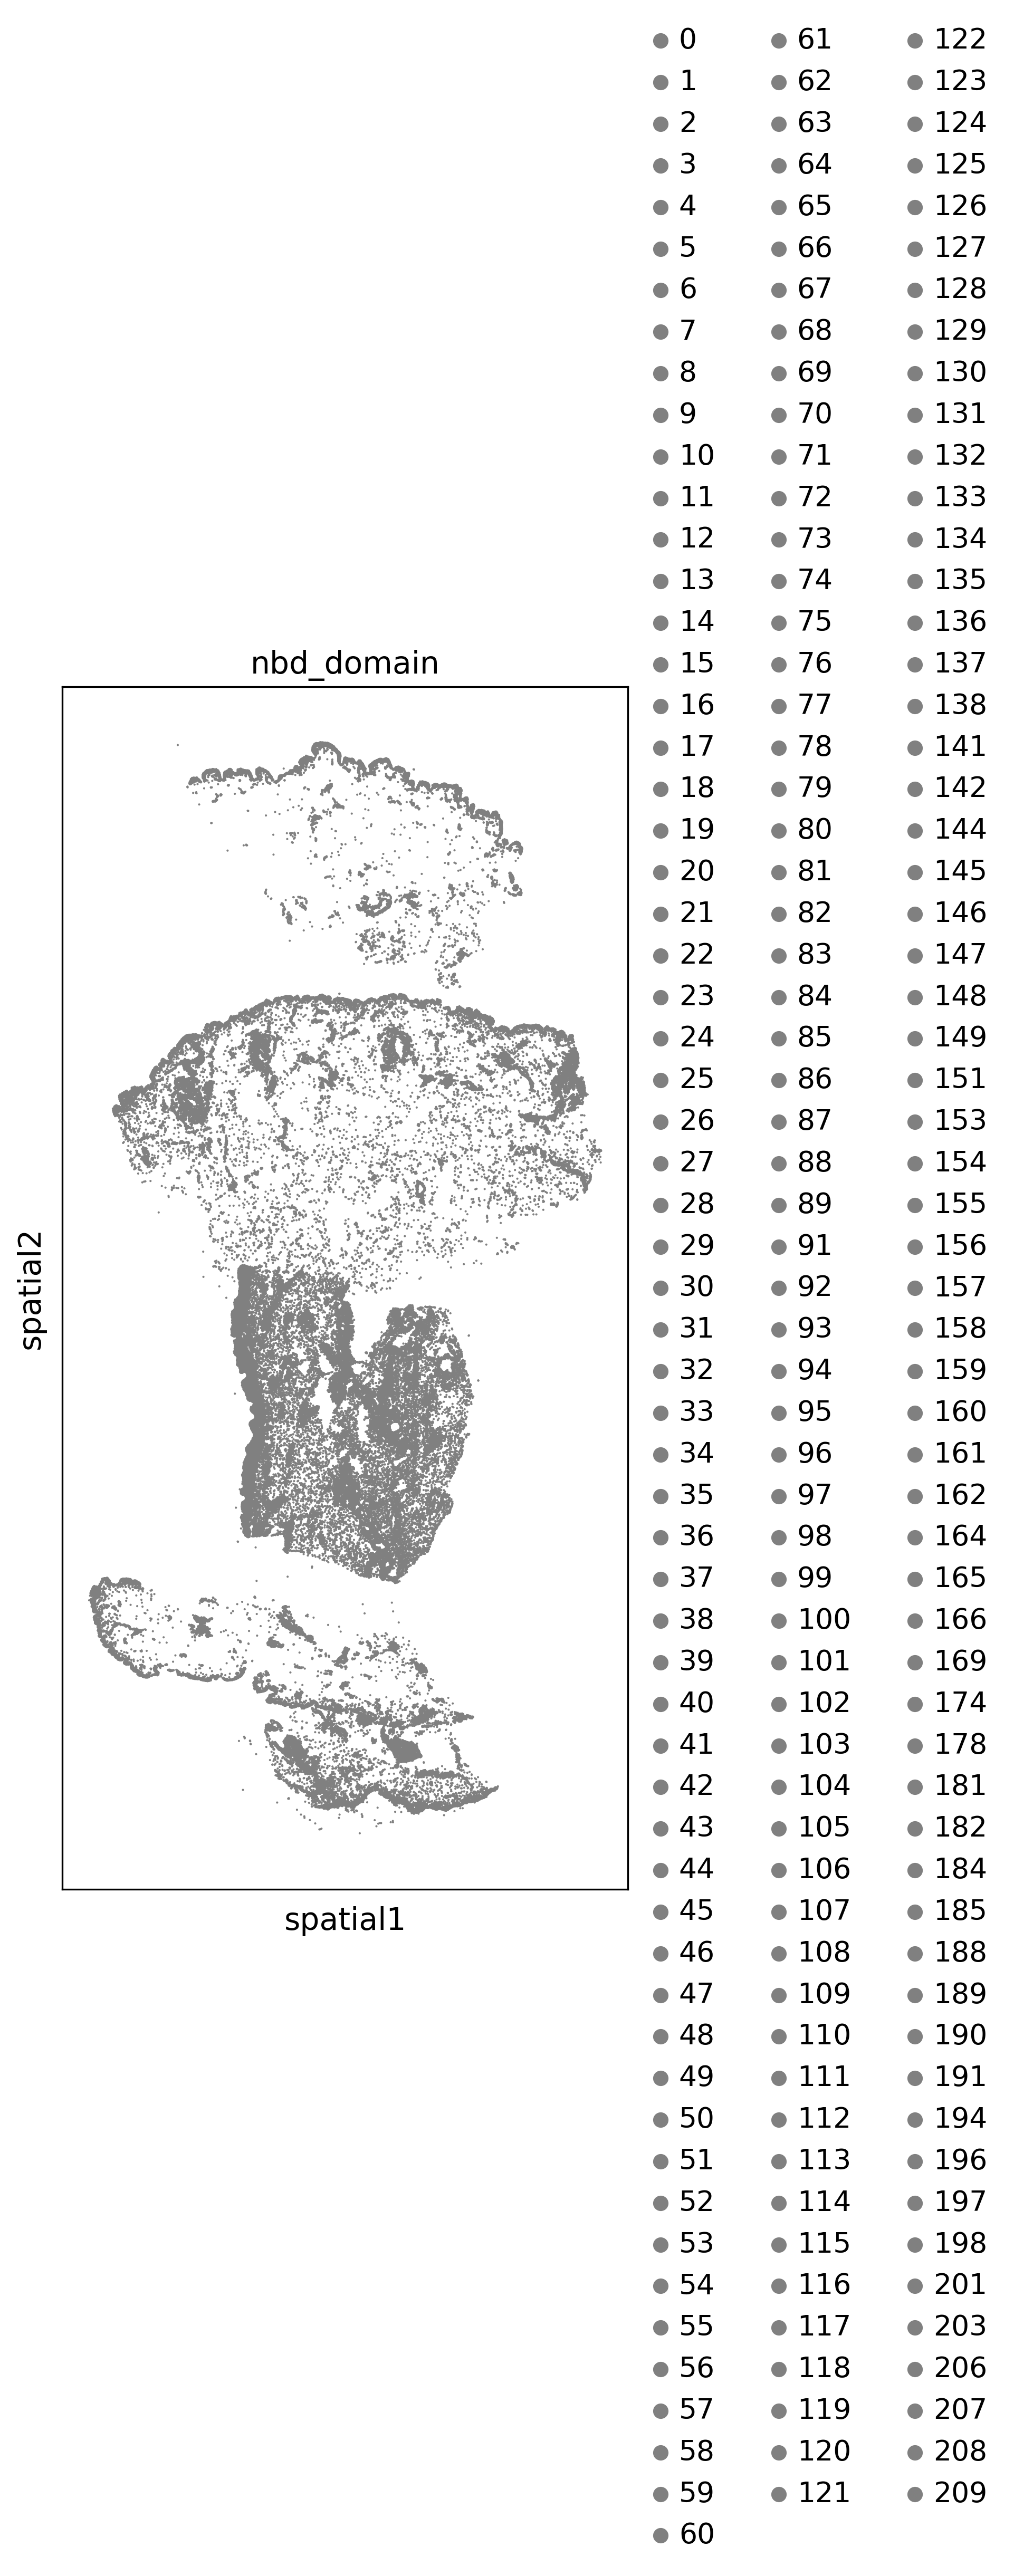

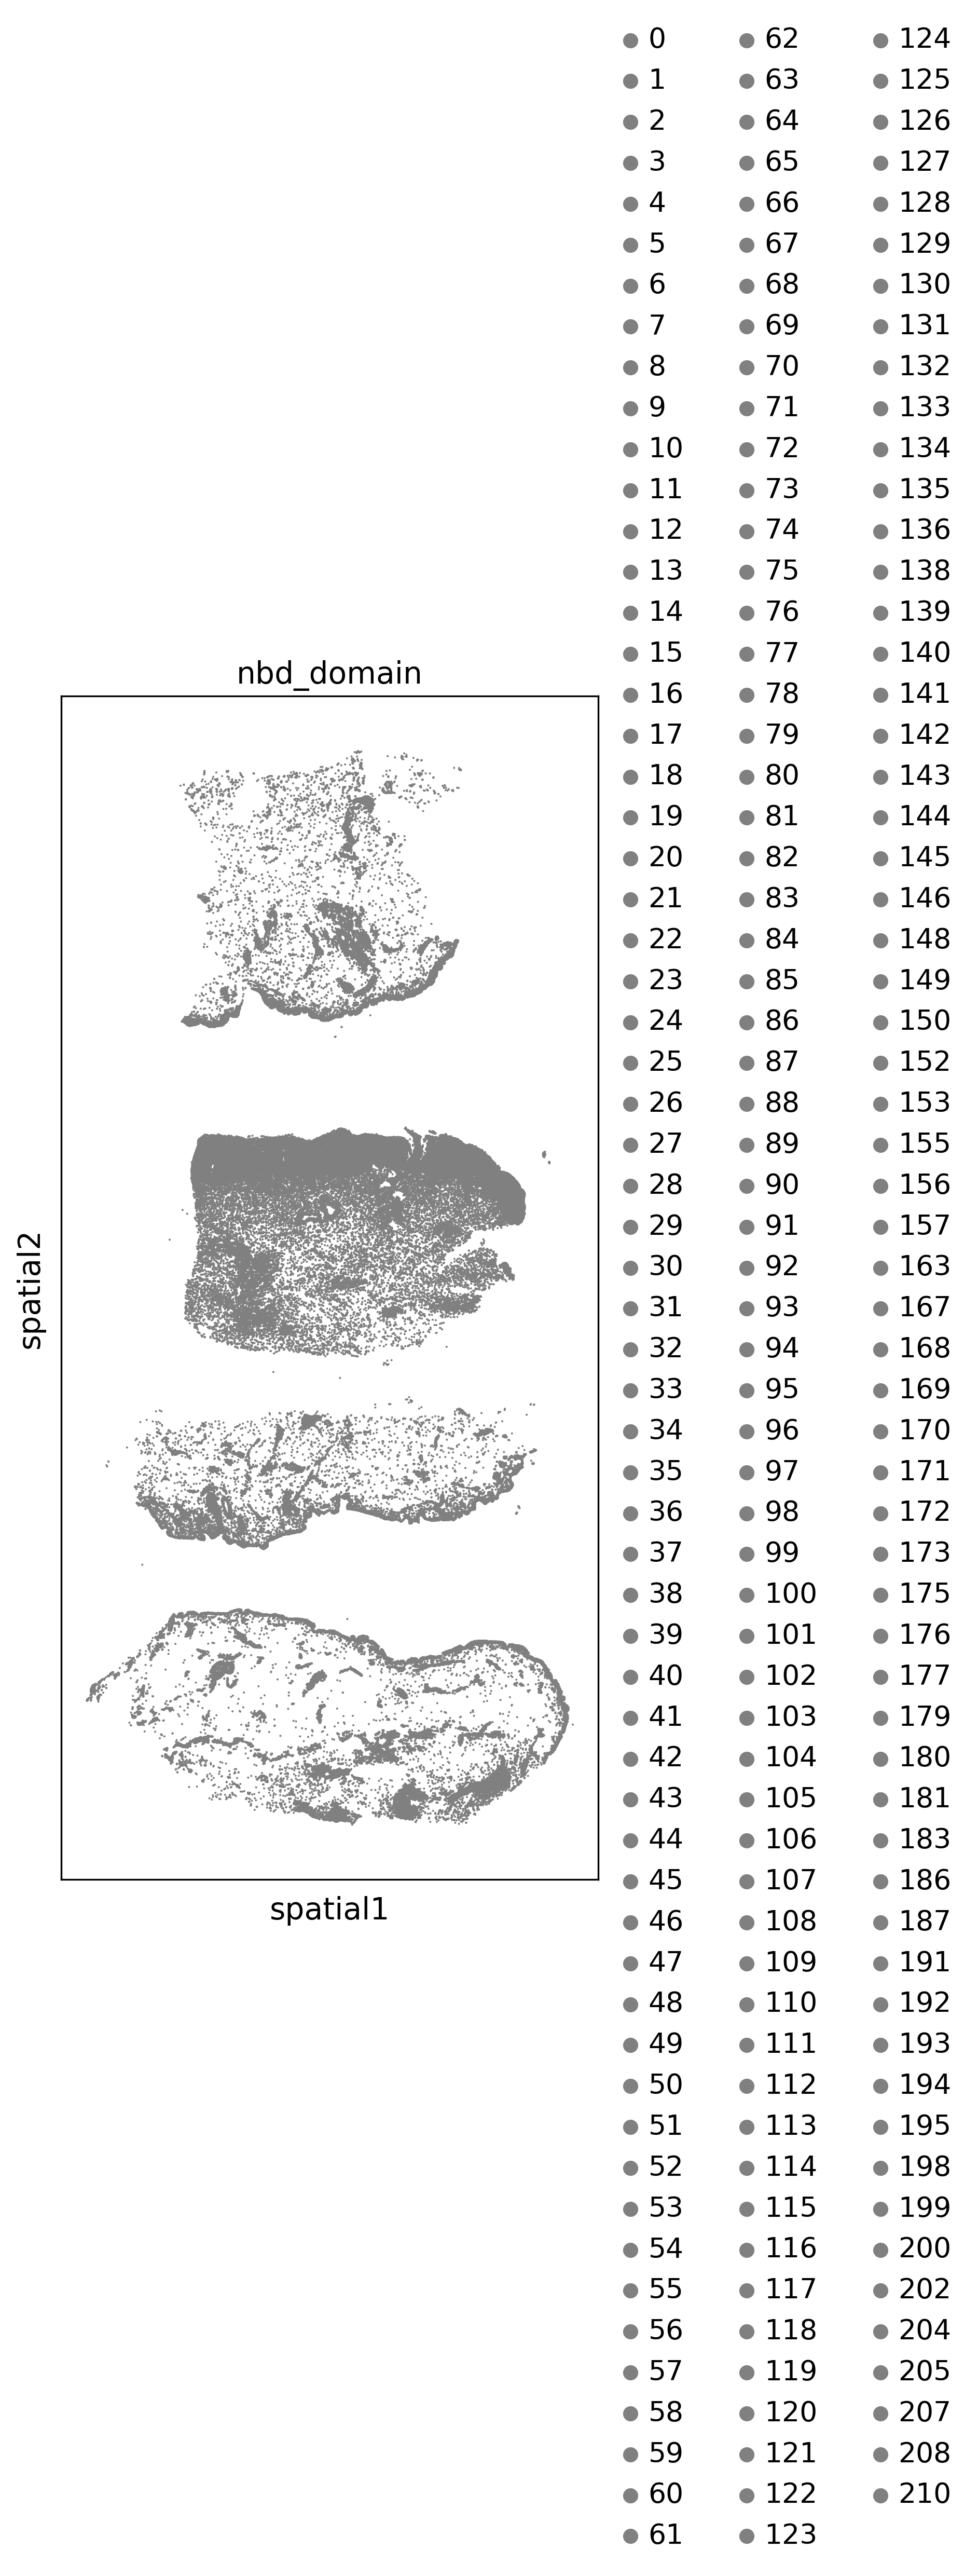

In [29]:
plot_domains(adata,groupby='nbd_domain')

### 4.3  Read-based domains identification (RBD)

In [30]:
hyperparameters_rbd={'key':'louvain_1.1','resolution':0.2,'neighbors':15,'clustering_algorithm':'leiden'}

In [ ]:
adata,adata_nbd=domains_by_rbd(adata,hyperparameters_rbd=hyperparameters_rbd)

 53%|████████████████████████████████████████████████████████▍                                                  | 136913/259789 [19:10<18:12, 112.49it/s]

### 4.4 Compare domains identified by different algorithms

In [ ]:
domain_keys=['rbd_domain','nbd_domain']#banksy_domain
ARI=compare_domains(adata,domain_keys=domain_keys,plot_path=plot_path,save=True)

### 5.1 Imputation using SpaGE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
from xb.Spage_main import * #make sure this works

Please specify where the single cell data in the format of h5ad is stored

In [ ]:
adata_sc=sc.read('./data/data_end_to_end_pipeline/scRNAseq.h5ad')

In [ ]:
adata_sc.X=adata_sc.X.todense()
adata_sc.X=adata_sc.X.astype('float64')
adata.X=adata.X.astype('float64')
adata=adata[:,adata.var.index.isin(adata_sc.var.index)]

In [ ]:
Imp_genes=leave_one_out_validation(adata,adata_sc,genes=['DRD1','DRD2'])

In [ ]:
new_genes = ['DRD1','DRD2']
Imp_New_Genes=gene_imputation(adata,adata_sc,new_genes)

### 6.Identifying Spatially variabile genes (SVF) by Squidpy's Moran I

In [ ]:
adata,hs_results=svf_moranI(adata,radius=50.0)

In [ ]:
hs_results.head(10)

## 7. Defining neighborhood enrichment of celltypes using Squidpy

In [ ]:
from xb.neighborhood import *

In [ ]:
adata=nhood_squidpy(adata,sample_key='sample',radius=50.0,cluster_key='louvain_1.1',plot_path=plot_path,cmap='Blues')